In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [2]:
vocab_size = 10000   # consider top 10,000 words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)


In [4]:
model = Sequential()

# Word embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length))

# Flatten embeddings
model.add(Flatten())

# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.7493 - loss: 0.4768 - val_accuracy: 0.8302 - val_loss: 0.3790
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.9603 - loss: 0.1161 - val_accuracy: 0.8384 - val_loss: 0.4294
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.9964 - loss: 0.0133 - val_accuracy: 0.8362 - val_loss: 0.5536
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.9998 - loss: 0.0014 - val_accuracy: 0.8432 - val_loss: 0.6010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 1.0000 - loss: 3.2766e-04 - val_accuracy: 0.8450 - val_loss: 0.6206
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 1.0000 - loss: 1.6649e-04 - val_accuracy: 0.8460 - val_loss: 0.6405
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 1.0000 - loss: 1.1021e-04 - val_accuracy: 0.8466 - val_loss: 0.6547
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 1.0000 -

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8487 - loss: 0.6644
Test Accuracy: 0.8486800193786621


In [8]:
predictions = model.predict(X_test)

print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {y_test[i]}, Predicted: {predictions[i][0]:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step

Sample Predictions:
Actual: 0, Predicted: 0.02
Actual: 1, Predicted: 1.00
Actual: 1, Predicted: 0.60
Actual: 0, Predicted: 0.02
Actual: 1, Predicted: 1.00


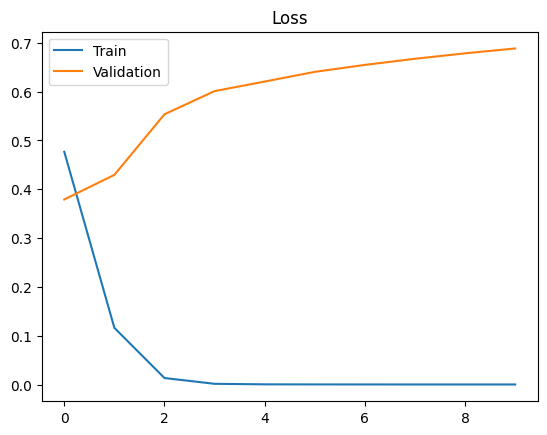

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

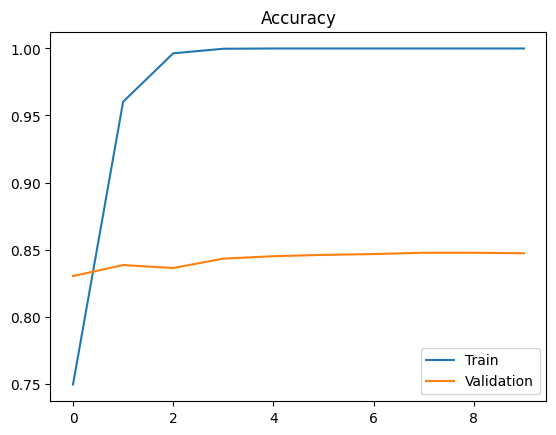

In [10]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()